# Single User Optimization Module Model

This notebook gives a reviewer-facing description of the single-user optimization model implemented by the single-user search layer.

The model takes one user deployment point and one required average downlink rate. It builds a discrete candidate space over PA choice, bandwidth part, PRB allocation, slot occupancy, spatial layers, active transmit chains, and MCS. Each candidate is then screened in two stages: a static rate/SINR stage and a dynamic power-feasibility stage.

The notebook follows that logic directly. I first fix one user case and the preset inputs, then summarize the resulting deployment and raw search space, then inspect the feasible candidate set that survives both screening stages, and finally interpret one selected feasible point as a time-frequency-layer resource block.


## 1. Explicit inputs and single-user case

The preset loaded by this notebook defines the radio environment and discrete sweep: link constants, PHY constants, bandwidth options, PRB step, admissible slot occupancies, admissible layer counts, MCS table, and PA catalog.

I then fix one concrete user case with a single distance and one required average downlink rate. There is no multi-distance or multi-rate sweep here; the purpose is to keep the model explanation tied to one deployment point and one target-rate constraint.


In [1]:
import os
import sys
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib import colors
import numpy as np
import pandas as pd
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from IPython.display import display

DOC_IMG_DIR = Path.cwd() / "img"
DOC_IMG_DIR.mkdir(parents=True, exist_ok=True)

NOTEBOOK_OUTER_PARALLEL = True
NOTEBOOK_MAX_WORKERS = max(1, os.cpu_count() or 1)


def export_doc_figure(fig, filename):
    output_path = DOC_IMG_DIR / filename
    fig.savefig(output_path, dpi=200, bbox_inches="tight")
    print(f"Saved figure to {output_path}")
    return output_path

sys.path.insert(0, str((Path.cwd() / "src").resolve()))

from single_user_study import (
    build_single_user_scenario,
    preview_single_user_candidates,
    run_single_user_scenario,
    summarize_single_user_scenario,
)


In [2]:
user_case = {
    "distance_m": 300.0,
    "rate_target_bps": 5e6,
}

scenario = build_single_user_scenario(
    distance_m=float(user_case["distance_m"]),
    required_rate_bps=float(user_case["rate_target_bps"]),
)
search_result = run_single_user_scenario(scenario)
search_views = summarize_single_user_scenario(scenario)
deployment_summary = search_views["deployment_summary"]
pa_characteristics = search_views["pa_characteristics"]
rrc_catalog = search_views["rrc_catalog"]
search_space_detail = search_views["search_space_detail"]
search_space_summary = search_views["search_space_summary"]

scheduler_sweep_table = search_space_detail.copy()
user_case_table = pd.DataFrame([user_case])

display(scheduler_sweep_table)
display(user_case_table)


,bandwidth_space_hz,layers_space,mcs_min,mcs_max,prb_step,mcs_entry_count
0,"(50000000.0, 100000000.0)","(1, 2, 3, 4)",0,28,5,29


,distance_m,rate_target_bps
0,300.0,5000000.0


## 2. Prepared deployment and discrete decision space

From these inputs, the model first builds one deployment state for the chosen user, including the path loss, carrier setting, slot-window length, and available transmit-chain budget.

For each PA and bandwidth option, the model then defines one RRC/BWP envelope. That envelope fixes the maximum PRB count implied by the bandwidth and subcarrier spacing, the maximum layer count implied by the transmitter, and the maximum admissible MCS. Inside each envelope, the discrete scheduler tuple is $(n_{\mathrm{PRB}}, n_{\mathrm{slots\ on}}, L, N_{\mathrm{active\ tx}}, \mathrm{MCS})$ with the structural constraints $1 \leq n_{\mathrm{PRB}} \leq n_{\mathrm{PRB,max}}$, $L \leq N_{\mathrm{active\ tx}} \leq N_{\mathrm{tx}}$, and MCS restricted to the allowed sweep. The tables below summarize that prepared deployment and the shape of the discrete decision space.


In [3]:
display(pa_characteristics)


,pa_id,pa_name,source_csv,n_curve_points,p_max_w,p_idle_w,eta_max,g_pa_eff_linear,g_pa_eff_db,kappa_distortion,backoff_db
0,0,Bae et al. NR,PA models\3.5Ghz_pas\4W_8W_NR_combined_NR_carr...,64,7.928899,5.239623,0.418165,1817.545759,32.594854,0.08,6.0
1,1,QPA9942,PA models\3.5Ghz_pas\4W_8W_NR_combined_NR_carr...,64,1.784671,0.641172,0.352236,935.848316,29.712055,0.08,6.0


## 3. Raw search-space summary for the chosen user

Before looking at feasible operating points, I summarize the size of the raw discrete space induced by this deployment.

This count is the combinatorial scheduler space before applying the target-rate cut or the PA feasibility test. It gives the reviewer a compact sense of how many structurally valid tuples the model must consider for one single-user case.


In [4]:
display(search_space_summary)


,pa_count,scenario_count,raw_configs_per_pa_per_scenario,raw_configs_per_scenario,raw_total_configs,n_slots_on_values,layers_values,n_active_tx_values,mcs_values,prb_step
0,2,1,487200,974400,974400,20,4,4,29,5


## 4. Candidate construction and staged filtering

I now show three compact views of the search logic.

First, the candidate preview exposes the raw tuple structure generated inside the RRC/BWP envelopes. Second, the feasibility count reports how many rows survive the full optimization model for this user case. Third, the selected-row table shows the best feasible operating point under the notebook ordering rule.

The screening itself happens in two stages. The model first computes each tuple's achievable average rate and its required SINR threshold from the MCS table, and it discards tuples whose achievable rate falls below the user target. It then evaluates the remaining tuples with the PA power model and keeps only the dynamically feasible rows. The returned candidate table is therefore already the strict feasible set for this user request, and the notebook only displays compact summaries of that set.


In [ ]:
PUBLIC_CONFIG_COLUMNS = [
    "distance_m",
    "path_loss_db",
    "pa_id",
    "pa_name",
    "rate_ach_bps",
    "p_dc_avg_total_w",
    "layers",
    "mcs",
    "n_prb",
    "n_slots_on",
    "bandwidth_hz",
    "n_active_tx",
    "p_out_total_w",
    "ps_total_w",
    "gamma_req_lin",
]
VARIABLE_COLUMNS = [
    "pa_name",
    "layers",
    "mcs",
    "n_prb",
    "n_slots_on",
    "bandwidth_hz",
    "n_active_tx",
    "rate_ach_bps",
    "p_dc_avg_total_w",
]
candidate_preview = preview_single_user_candidates(scenario).copy()
candidate_table = search_result.copy().reset_index(drop=True)
feasible_table = candidate_table.copy()

feasibility_summary = pd.DataFrame(
    [
        {
            "candidate_space": "returned_feasible_space",
            "count": int(len(candidate_table)),
        }
    ]
)

best_feasible_row = (
    feasible_table.sort_values(["p_dc_avg_total_w", "bandwidth_hz", "n_prb", "n_slots_on"])
    .reset_index(drop=True)
    .iloc[0]
    if not feasible_table.empty
    else None
)
best_feasible = (
    pd.DataFrame([best_feasible_row[PUBLIC_CONFIG_COLUMNS]])
    if best_feasible_row is not None
    else pd.DataFrame(columns=PUBLIC_CONFIG_COLUMNS)
)

display(candidate_preview)
display(feasibility_summary)
display(best_feasible)


,pa_id,bwp_idx,n_prb,n_slots_on,layers,n_active_tx,mcs
0,0,0,1,1,1,1,0
1,0,0,1,1,1,1,1
2,0,0,1,1,1,1,2
3,0,0,1,1,1,1,3
4,0,0,1,1,1,1,4


,candidate_space,count
0,returned_feasible_space,580784


,distance_m,path_loss_db,pa_id,pa_name,rate_ach_bps,p_dc_avg_total_w,layers,mcs,n_prb,n_slots_on,bandwidth_hz,n_active_tx,p_out_total_w,ps_total_w,gamma_req_lin
0,300.0,125.437181,1,QPA9942,5103129.6,2.564688,3,11,6,16,50000000.0,4,0.124868,0.000133,3.656352


## 5. Compact feasible-space readout across PA choices

Having constructed the strict feasible set, I next examine its geometry across the PA choices.

I aggregate feasible rows by PA and plot achievable rate against average PA DC power. This gives a compact view of how the feasible operating region shifts across amplifier options and helps the reviewer see whether the displayed best row is isolated or part of a broader low-power frontier.


In [20]:
feasible_summary_by_pa = (
    feasible_table.groupby(["pa_id", "pa_name"], dropna=False)
    .agg(
        feasible_rows=("rate_ach_bps", "size"),
        min_rate_bps=("rate_ach_bps", "min"),
        max_rate_bps=("rate_ach_bps", "max"),
        min_power_w=("p_dc_avg_total_w", "min"),
        max_power_w=("p_dc_avg_total_w", "max"),
    )
    .reset_index()
)
display(feasible_summary_by_pa)

,pa_id,pa_name,feasible_rows,min_rate_bps,max_rate_bps,min_power_w,max_power_w
0,0,Bae et al. NR,333670,5000032.8,681026688.0,20.958493,75.603038
1,1,QPA9942,247114,5000032.8,327677952.0,2.564688,20.262522


distance_m                300.0
pa_name                 QPA9942
layers                        2
mcs                           6
n_prb                        76
n_slots_on                   11
bandwidth_hz        100000000.0
n_active_tx                   2
rate_ach_bps         17596128.0
p_dc_avg_total_w       3.636067
Name: 384822, dtype: object

,pa_id,pa_name,feasible_rows,min_rate_bps,max_rate_bps,min_power_w,max_power_w
0,0,Bae et al. NR,333670,5000032.8,681026688.0,20.958493,75.603038
1,1,QPA9942,247114,5000032.8,327677952.0,2.564688,20.262522


Saved figure to c:\Users\henry\Documents\Masters Thesis\code\img\single_user_resource_allocation_feasible_points.png


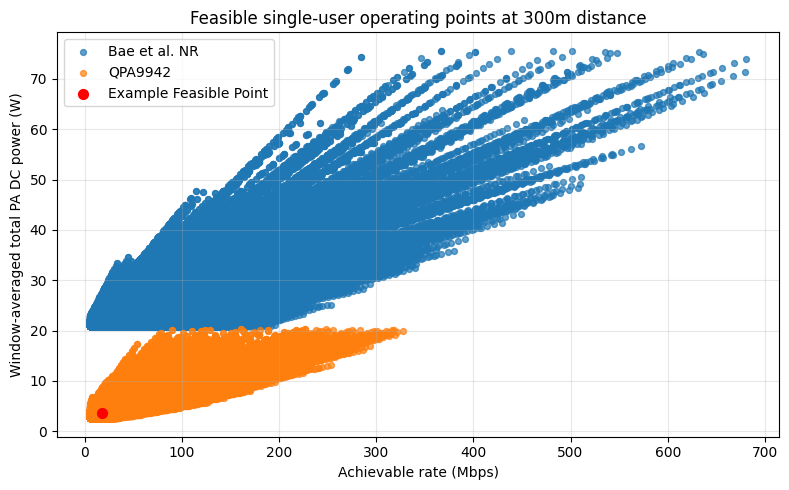

In [24]:
# get and example feasible row for visualization from the table
rand_int = np.random.randint(0, len(feasible_table) - 1)
example_feasible_row = feasible_table.iloc[rand_int]
display_row = example_feasible_row[VARIABLE_COLUMNS]
display(display_row)


feasible_summary_by_pa = (
    feasible_table.groupby(["pa_id", "pa_name"], dropna=False)
    .agg(
        feasible_rows=("rate_ach_bps", "size"),
        min_rate_bps=("rate_ach_bps", "min"),
        max_rate_bps=("rate_ach_bps", "max"),
        min_power_w=("p_dc_avg_total_w", "min"),
        max_power_w=("p_dc_avg_total_w", "max"),
    )
    .reset_index()
)
display(feasible_summary_by_pa)

fig, ax = plt.subplots(figsize=(8, 5))
for pa_id, df_pa in feasible_table.groupby("pa_id", sort=True):
    ax.scatter(
        df_pa["rate_ach_bps"] / 1e6,
        df_pa["p_dc_avg_total_w"],
        s=18,
        alpha=0.7,
        label=df_pa["pa_name"].iloc[0],
    )

# colour the example feasible point in red and label it
ax.scatter(
    display_row["rate_ach_bps"] / 1e6,
    display_row["p_dc_avg_total_w"],
    s=50,
    color="red",
    label="Example Feasible Point"
)

ax.set_xlabel("Achievable rate (Mbps)")
ax.set_ylabel("Window-averaged total PA DC power (W)")
ax.set_title("Feasible single-user operating points at 300m distance")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
export_doc_figure(fig, "single_user_resource_allocation_feasible_points.png")
plt.show()


## 6. Resource interpretation of the selected feasible row

The optimization model returns a feasible set rather than one mandatory winner. For exposition, I order the feasible rows by average PA DC power, then bandwidth, PRB count, and slot count, and I display the first row in that ordering.

I then interpret that row as one cuboid inside the available BWP, slot-window, and spatial-layer envelope. This is not a packet-level schedule; it is a compact geometric view of how much frequency, time, and spatial depth are consumed by one feasible operating point while meeting the user's average-rate requirement.


,pa_name,mcs,layers,allocated_prbs,available_prbs,allocated_slots,available_slots,rate_ach_mbps,window_avg_total_pa_dc_w
0,QPA9942,11,3,6,139,16,20,5.10313,2.564688


Saved figure to c:\Users\henry\Documents\Masters Thesis\code\img\single_user_resource_allocation_candidate.png


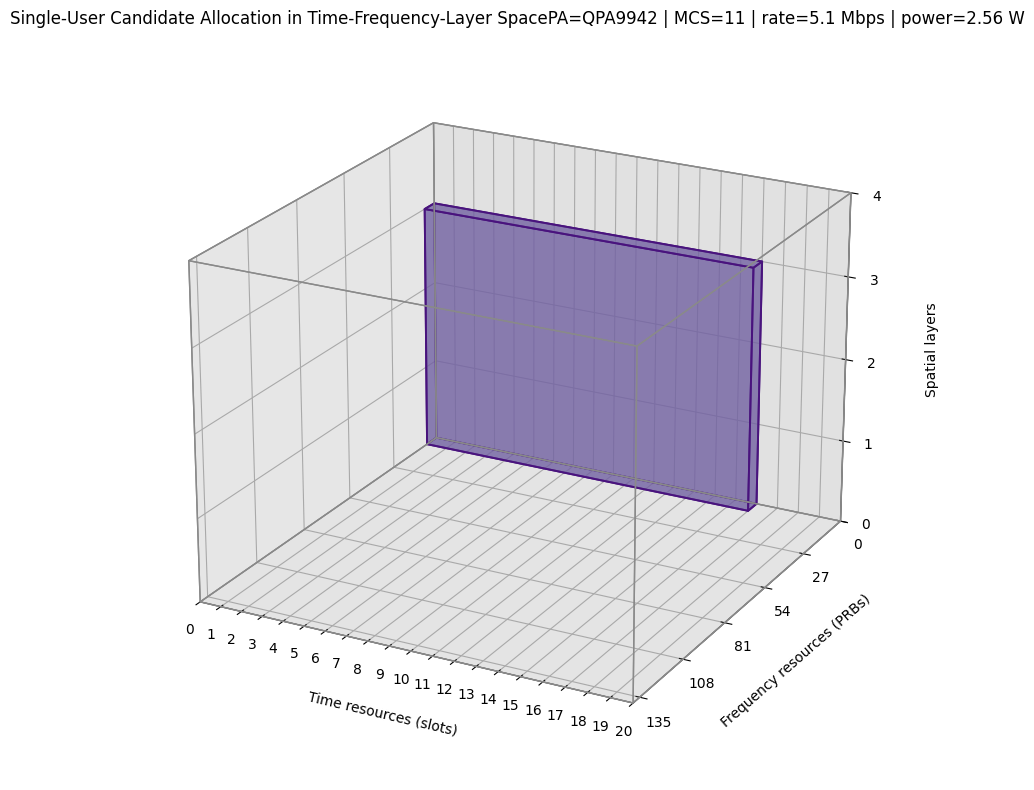

In [ ]:


candidate_summary = pd.DataFrame(
    [
        {
            "pa_name": candidate_block["pa_name"],
            "mcs": candidate_block["mcs"],
            "layers": candidate_block["layer_count"],
            "allocated_prbs": candidate_block["prb_count"],
            "available_prbs": TOTAL_PRBS,
            "allocated_slots": candidate_block["slot_count"],
            "available_slots": TOTAL_SLOTS,
            "rate_ach_mbps": candidate_block["rate_mbps"],
            "window_avg_total_pa_dc_w": candidate_block["power_w"],
        }
    ]
)
display(candidate_summary)


def cuboid(ax, x, y, z, dx, dy, dz, color, alpha=0.45, edgecolor="black", linewidth=1.2):
    v = np.array([
        [x, y, z],
        [x + dx, y, z],
        [x + dx, y + dy, z],
        [x, y + dy, z],
        [x, y, z + dz],
        [x + dx, y, z + dz],
        [x + dx, y + dy, z + dz],
        [x, y + dy, z + dz],
    ])

    faces = [
        [v[i] for i in [0, 1, 2, 3]],
        [v[i] for i in [4, 5, 6, 7]],
        [v[i] for i in [0, 1, 5, 4]],
        [v[i] for i in [2, 3, 7, 6]],
        [v[i] for i in [1, 2, 6, 5]],
        [v[i] for i in [0, 3, 7, 4]],
    ]

    poly = Poly3DCollection(
        faces,
        facecolors=color,
        edgecolor=edgecolor,
        linewidths=linewidth,
        alpha=alpha,
    )
    ax.add_collection3d(poly)


fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

envelope_color = colors.to_hex(plt.cm.Greys(0.55))
allocation_color = colors.to_hex(plt.cm.Purples(0.72))

cuboid(
    ax,
    0,
    0,
    0,
    TOTAL_SLOTS,
    TOTAL_PRBS,
    MAX_LAYERS,
    envelope_color,
    alpha=0.08,
    edgecolor="#8a8a8a",
    linewidth=1.0,
)

cuboid(
    ax,
    candidate_block["slot_start"],
    0,
    0,
    candidate_block["slot_count"],
    candidate_block["prb_count"],
    candidate_block["layer_count"],
    allocation_color,
    alpha=0.55,
    edgecolor="#3f007d",
    linewidth=1.4,
)

ax.set_xlabel("Time resources (slots)", labelpad=12)
ax.set_ylabel("Frequency resources (PRBs)", labelpad=14)
ax.zaxis.set_rotate_label(False)
ax.set_zlabel("Spatial layers", rotation=90, labelpad=18)

ax.set_xlim(0, TOTAL_SLOTS)
ax.set_ylim(TOTAL_PRBS, 0)
ax.set_zlim(0, MAX_LAYERS)
ax.set_xticks(np.arange(0, TOTAL_SLOTS + 1, 1))
ax.set_yticks(np.arange(0, TOTAL_PRBS + 1, max(1, TOTAL_PRBS // 5)))
ax.set_zticks(np.arange(0, MAX_LAYERS + 1, 1))
ax.set_title(
    "Single-User Candidate Allocation in Time-Frequency-Layer Space"
    f"PA={candidate_block['pa_name']} | MCS={candidate_block['mcs']} | "
    f"rate={candidate_block['rate_mbps']:.1f} Mbps | power={candidate_block['power_w']:.2f} W"
)
ax.view_init(elev=22, azim=-62)
plt.tight_layout()
export_doc_figure(fig, "single_user_resource_allocation_candidate.png")
plt.show()
